# Caption Quality Evaluation (FashionStyle14 Dataset2, Qwen Captions)

## Objective
This notebook evaluates **Qwen-generated captions** in `FashionStyle14_v1/caption/qwen_full_captions.csv` using eight caption-quality metrics. Each metric runs on the **test split** of stratified train/val/test partitions defined by robustness seeds in `seeds_list.txt`.

## Metrics (summary)
| Metric | What it measures | Better |
|--------|------------------|--------|
| CLIP Similarity | Global image-caption semantic alignment (cosine) | Higher |
| CLIP-IQA | Correct caption vs random captions (relative margin) | Higher |
| BLIPScore | BLIP image-text matching (ITM) | Higher |
| Retrieval Recall@K | Image/text cross-retrieval in embedding space | Higher |
| Confusion Matrix | Style prediction from image+caption vs ground truth | Lower off-diagonal |
| GPT-4o Evaluation | LLM judgment of correctness and style fit | Higher |
| Random Caption Sanity | Accuracy drop when captions are shuffled | Larger drop |
| Class-Randomized Sanity | Accuracy drop when captions come from other styles | Larger drop |

## Configuration
- Set `USE_ALL_SEEDS = False` and `NUM_SEEDS_TO_USE = 10` to run the **first 10** seeds (default, matches other notebooks).
- Set `USE_ALL_SEEDS = True` to run **all 30** seeds from `seeds_list.txt`.
- Optional `MAX_SAMPLES_PER_EVAL` subsamples the test set per seed for faster debugging.

## Inputs
| Path | Role |
|------|------|
| `FashionStyle14_v1/complete_dataset2.csv` | Image list (dataset2) |
| `FashionStyle14_v1/caption/qwen_full_captions.csv` | Captions |
| `FashionStyle14_v1/seeds_list.txt` | Split seeds |
| `FashionStyle14_v1/dataset2/` | Image files (all style subfolders) |

## Outputs
All artifacts are written under **`robustness/qwen_caption_evaluation_dataset2/<metric_name>/`**:
- Per-seed CSV/JSON scores
- `all_seeds_summary.csv` (one row per seed)
- Figures (PNG) where applicable
- Printed **mean +/- std** after each metric section

Code, comments, and plots use **English only**.


## 1. Configuration, imports, and paths


In [8]:
from __future__ import annotations

import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModel,
    AutoTokenizer,
    BlipForImageTextRetrieval,
    BlipProcessor,
    CLIPModel,
    CLIPProcessor,
)

warnings.filterwarnings("ignore", category=UserWarning)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# --- Seed scope (first 10 vs all 30) ---
USE_ALL_SEEDS = True
NUM_SEEDS_TO_USE = 30

# --- Evaluation scope ---
MAX_SAMPLES_PER_EVAL: Optional[int] = None  # e.g. 200 for quick runs; None = full test set
EVAL_BATCH_SIZE = 32
RETRIEVAL_K_VALUES = [1, 5, 10]
OVERWRITE_EXISTING = False
RANDOM_CAPTION_SANITY_SEED = 42
CLASS_RANDOM_SANITY_SEED = 43

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
BLIP_ITM_MODEL_ID = "Salesforce/blip-itm-base-coco"
BERT_MODEL_ID = "bert-base-uncased"

SANITY_TRAIN_EPOCHS = 8
SANITY_BATCH_SIZE = 16
SANITY_LR = 5e-4
SANITY_DROPOUT = 0.5

GPT4O_MODEL = "gpt-4o"
GPT4O_MAX_SAMPLES_PER_SEED = 50
SKIP_GPT4O_IF_NO_KEY = True

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


def load_seeds(seeds_file: Path) -> List[int]:
    content = seeds_file.read_text(encoding="utf-8")
    matches = re.findall(r"Seed\s+(\d+)", content, flags=re.IGNORECASE)
    seeds = sorted({int(s) for s in matches if 1 <= int(s) <= 500})
    if len(seeds) != 30:
        print(f"Warning: expected 30 seeds in file, found {len(seeds)}")
    return seeds


# Direct paths (dataset2 images + complete_dataset2.csv)
DATA_DIR = Path(r"../FashionStyle14_v1")
IMAGE_ROOT = DATA_DIR
IMAGE_DATASET_DIR = DATA_DIR / "dataset2"
COMPLETE_CSV = DATA_DIR / "complete_dataset2.csv"
CAPTION_CSV = DATA_DIR / "caption" / "qwen_full_captions.csv"
SEEDS_FILE = DATA_DIR / "seeds_list.txt"
RESULTS_ROOT = Path(r"./qwen_caption_evaluation")

DATASET_FOLDER = "dataset2"

ALL_PARSED_SEEDS = load_seeds(SEEDS_FILE)
SEEDS = ALL_PARSED_SEEDS if USE_ALL_SEEDS else ALL_PARSED_SEEDS[:NUM_SEEDS_TO_USE]
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
print("DATA_DIR:", DATA_DIR)
print("IMAGE_DATASET_DIR:", IMAGE_DATASET_DIR)
print("COMPLETE_CSV:", COMPLETE_CSV)
print("CAPTION_CSV:", CAPTION_CSV)
print("RESULTS_ROOT:", RESULTS_ROOT)
print(f"Seed mode: {'ALL' if USE_ALL_SEEDS else f'FIRST {NUM_SEEDS_TO_USE}'} -> {len(SEEDS)} seeds")
print("SEEDS:", SEEDS)

DATA_DIR: ..\FashionStyle14_v1
IMAGE_DATASET_DIR: ..\FashionStyle14_v1\dataset2
COMPLETE_CSV: ..\FashionStyle14_v1\complete_dataset2.csv
CAPTION_CSV: ..\FashionStyle14_v1\caption\qwen_full_captions.csv
RESULTS_ROOT: qwen_caption_evaluation
Seed mode: ALL -> 30 seeds
SEEDS: [13, 14, 16, 17, 45, 48, 53, 58, 72, 102, 112, 115, 120, 126, 141, 215, 217, 259, 280, 288, 303, 309, 328, 333, 347, 360, 367, 378, 380, 457]


## 2. Hardware and device


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    total_mem_gb = props.total_memory / (1024**3)
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {total_mem_gb:.2f} GB")
    if total_mem_gb < 8:
        EVAL_BATCH_SIZE = min(EVAL_BATCH_SIZE, 16)
        SANITY_BATCH_SIZE = min(SANITY_BATCH_SIZE, 8)
else:
    print("CUDA not available; using CPU (slower).")
    EVAL_BATCH_SIZE = min(EVAL_BATCH_SIZE, 8)
    SANITY_BATCH_SIZE = min(SANITY_BATCH_SIZE, 8)

print("device:", device)
print("EVAL_BATCH_SIZE:", EVAL_BATCH_SIZE)
print("SANITY_BATCH_SIZE:", SANITY_BATCH_SIZE)
print("use_amp:", use_amp)

CUDA device: NVIDIA GeForce RTX 3060 Ti
Total GPU memory: 8.00 GB
device: cuda
EVAL_BATCH_SIZE: 16
SANITY_BATCH_SIZE: 8
use_amp: True


## 3. Load dataset, captions, and split helpers


In [10]:
def normalize_rel_path(path_str: str) -> str:
    return str(path_str).strip().replace("\\", "/")


def resolve_abs_path(raw: str) -> str:
    """Map merge_key (dataset2/<style>/<file>) to an on-disk path under IMAGE_ROOT."""
    key = canonical_merge_key(raw)
    return str((IMAGE_ROOT / key.replace("/", os.sep)).resolve())


def canonical_merge_key(raw: str) -> str:
    """Normalize paths so image list and caption CSV join on dataset2/<style>/<file>."""
    s = normalize_rel_path(raw).lstrip("./")
    low = s.lower()

    prefixes = ("fashionstyle14_v1/",)
    changed = True
    while changed:
        changed = False
        for pref in prefixes:
            if low.startswith(pref):
                s = s[len(pref) :].lstrip("/")
                low = s.lower()
                changed = True
                break

    for marker in ("dataset2/", "dataset/"):
        ix = low.find(marker)
        if ix >= 0:
            key = normalize_rel_path(s[ix:])
            if key.lower().startswith("dataset/"):
                key = f"{DATASET_FOLDER}/" + key.split("/", 1)[1]
            return key

    p = Path(s)
    if p.is_absolute():
        root = IMAGE_ROOT.resolve()
        try:
            rel = Path(p.resolve()).relative_to(root)
            return canonical_merge_key(str(rel).replace(os.sep, "/"))
        except ValueError:
            pass

    if "/" in s and not low.startswith(f"{DATASET_FOLDER}/"):
        return f"{DATASET_FOLDER}/{s.lstrip('/')}"

    return s


def load_complete_dataset(csv_path: Path) -> pd.DataFrame:
    if not csv_path.is_file():
        raise FileNotFoundError(f"complete_dataset2.csv not found: {csv_path}")
    if not IMAGE_DATASET_DIR.is_dir():
        raise FileNotFoundError(f"dataset2 folder not found: {IMAGE_DATASET_DIR}")

    lines = csv_path.read_text(encoding="utf-8").splitlines()
    rel = [ln.strip() for ln in lines if ln.strip()]
    df = pd.DataFrame({"rel_path": rel})
    df["rel_path"] = df["rel_path"].map(normalize_rel_path)
    df["merge_key"] = df["rel_path"].map(canonical_merge_key)
    df["style"] = df["merge_key"].str.split("/").str[1]
    df["abs_path"] = df["rel_path"].map(resolve_abs_path)
    n_raw = len(df)
    df = df[df["abs_path"].map(os.path.isfile)].reset_index(drop=True)
    if len(df) == 0:
        raise FileNotFoundError(
            f"No image files found under {IMAGE_DATASET_DIR}. "
            f"complete_dataset2.csv has {n_raw} rows but 0 resolved paths exist on disk."
        )
    if len(df) < n_raw:
        print(f"Warning: dropped {n_raw - len(df)} CSV rows with missing image files")
    return df


def load_captions_long(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8")
    work = df.copy()
    if "status" in work.columns:
        work = work[work["status"].astype(str).str.lower() == "success"]
    path_aliases = {"image_path", "rel_path", "path", "filename", "file_path", "filepath", "image"}
    path_col = next((c for c in work.columns if c.lower().strip() in path_aliases), None)
    cap_col = next((c for c in work.columns if c.lower().strip() in {"caption", "text", "description"}), None)
    if cap_col is None:
        caption_named = [c for c in work.columns if "caption" in str(c).lower()]
        cap_col = caption_named[0] if caption_named else None
    if path_col is None or cap_col is None:
        raise ValueError(f"Caption CSV columns invalid: {list(work.columns)}")
    out = work[[path_col, cap_col]].rename(columns={path_col: "raw_image_path", cap_col: "caption"})
    out["merge_key"] = out["raw_image_path"].map(canonical_merge_key)
    out["caption"] = out["caption"].fillna("").astype(str).str.strip()
    out = out[out["caption"] != ""].drop_duplicates(subset=["merge_key"], keep="last")
    return out.reset_index(drop=True)


df_paths = load_complete_dataset(COMPLETE_CSV)
cap_df = load_captions_long(CAPTION_CSV)
df_full = df_paths.merge(cap_df[["merge_key", "caption"]], on="merge_key", how="inner").reset_index(drop=True)

if len(df_full) == 0:
    inter = len(set(df_paths["merge_key"]) & set(cap_df["merge_key"]))
    print("DEBUG dataset merge_keys:", df_paths["merge_key"].head(5).tolist())
    print("DEBUG caption merge_keys:", cap_df["merge_key"].head(5).tolist())
    print("DEBUG |paths|", len(df_paths), "|captions|", len(cap_df), "|intersection|", inter)
    raise ValueError(
        "No rows after joining images and captions. Check complete_dataset2.csv paths "
        "and caption CSV paths (expected dataset2/<style>/<file>)."
    )

classes = sorted(df_full["style"].unique().tolist())
assert len(classes) == 14, f"Expected 14 classes, got {len(classes)}: {classes}"
style_to_idx = {s: i for i, s in enumerate(classes)}
idx_to_style = {i: s for s, i in style_to_idx.items()}
num_classes = len(classes)

print("Samples with captions:", len(df_full))
print("Number of classes:", num_classes)
print("Classes:", classes)
print("Example data:")
print(df_full.head())

def split_by_seed(df: pd.DataFrame, seed_value: int):
    train_df, temp_df = train_test_split(
        df,
        test_size=(VAL_RATIO + TEST_RATIO),
        stratify=df["style"],
        random_state=seed_value,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        stratify=temp_df["style"],
        random_state=seed_value,
    )
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def subsample_test_df(test_df: pd.DataFrame) -> pd.DataFrame:
    if MAX_SAMPLES_PER_EVAL is None or len(test_df) <= MAX_SAMPLES_PER_EVAL:
        return test_df
    return test_df.sample(n=MAX_SAMPLES_PER_EVAL, random_state=42).reset_index(drop=True)


def metric_dir(name: str) -> Path:
    p = RESULTS_ROOT / name
    p.mkdir(parents=True, exist_ok=True)
    return p


def print_mean_std_table(df: pd.DataFrame, value_cols: List[str], title: str) -> pd.DataFrame:
    rows = []
    print(f"\n=== {title}: mean +/- std across seeds ===")
    for col in value_cols:
        if col not in df.columns:
            continue
        vals = df[col].astype(float).dropna()
        mean_v, std_v = float(vals.mean()), float(vals.std(ddof=0))
        rows.append({"metric": col, "mean": mean_v, "std": std_v})
        print(f"  {col}: {mean_v:.4f} +/- {std_v:.4f}  (n={len(vals)})")
    summary = pd.DataFrame(rows)
    return summary


def save_summary_csv(summary: pd.DataFrame, out_path: Path) -> None:
    summary.to_csv(out_path, index=False)
    print("Saved summary:", out_path)


@torch.no_grad()
def load_pil_batch(paths: List[str]) -> List[Image.Image]:
    return [Image.open(p).convert("RGB") for p in paths]

print("Data helpers ready.")

Samples with captions: 13127
Number of classes: 14
Classes: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Example data:
                                       rel_path  \
0           ../dataset2/conservative/00-254.jpg   
1           ../dataset2/conservative/00-795.jpg   
2      ../dataset2/conservative/00000274_02.jpg   
3   ../dataset2/conservative/00100_05_00938.jpg   
4  ../dataset2/conservative/001969733001_12.jpg   

                                   merge_key         style  \
0           dataset2/conservative/00-254.jpg  conservative   
1           dataset2/conservative/00-795.jpg  conservative   
2      dataset2/conservative/00000274_02.jpg  conservative   
3   dataset2/conservative/00100_05_00938.jpg  conservative   
4  dataset2/conservative/001969733001_12.jpg  conservative   

                                            abs_path  \
0  C:\Users\Sandy\OneDrive\桌面\255\Fusion

## 4. Evaluation Metrics

### CLIP Similarity

Image + Caption -> CLIP embeddings -> cosine similarity. **Higher is better.**


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[clip_similarity] seed_13 (1/30): mean=0.3174 n=1970
[clip_similarity] seed_14 (2/30): mean=0.3160 n=1970
[clip_similarity] seed_16 (3/30): mean=0.3163 n=1970
[clip_similarity] seed_17 (4/30): mean=0.3164 n=1970
[clip_similarity] seed_45 (5/30): mean=0.3165 n=1970
[clip_similarity] seed_48 (6/30): mean=0.3175 n=1970
[clip_similarity] seed_53 (7/30): mean=0.3157 n=1970
[clip_similarity] seed_58 (8/30): mean=0.3165 n=1970
[clip_similarity] seed_72 (9/30): mean=0.3167 n=1970
[clip_similarity] seed_102 (10/30): mean=0.3167 n=1970
[clip_similarity] seed_112 (11/30): mean=0.3159 n=1970
[clip_similarity] seed_115 (12/30): mean=0.3170 n=1970
[clip_similarity] seed_120 (13/30): mean=0.3172 n=1970
[clip_similarity] seed_126 (14/30): mean=0.3156 n=1970
[clip_similarity] seed_141 (15/30): mean=0.3172 n=1970
[clip_similarity] seed_215 (16/30): mean=0.3172 n=1970
[clip_similarity] seed_217 (17/30): mean=0.3169 n=1970
[clip_similarity] seed_259 (18/30): mean=0.3166 n=1970
[clip_similarity] seed_280 (

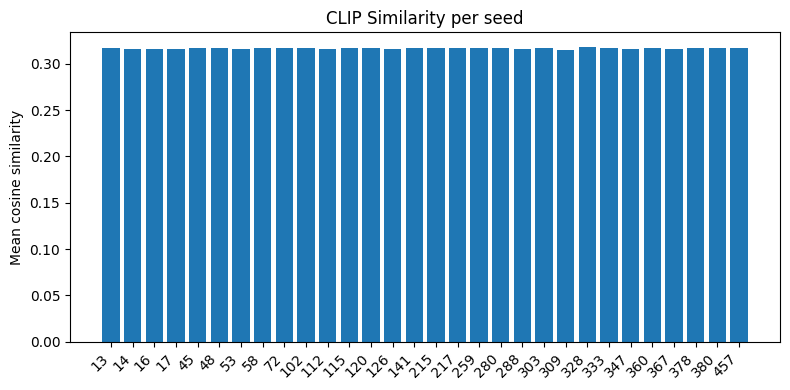

    seed  clip_similarity_mean  n_test
0     13              0.317434    1970
1     14              0.316025    1970
2     16              0.316272    1970
3     17              0.316360    1970
4     45              0.316543    1970
5     48              0.317486    1970
6     53              0.315729    1970
7     58              0.316529    1970
8     72              0.316656    1970
9    102              0.316729    1970
10   112              0.315939    1970
11   115              0.317010    1970
12   120              0.317231    1970
13   126              0.315610    1970
14   141              0.317239    1970
15   215              0.317245    1970
16   217              0.316874    1970
17   259              0.316562    1970
18   280              0.316727    1970
19   288              0.316314    1970
20   303              0.317369    1970
21   309              0.314814    1970
22   328              0.317987    1970
23   333              0.317116    1970
24   347              0.3

In [11]:
def clip_cosine_similarity_batch(clip_model, clip_processor, paths, captions, device, batch_size):
    scores = []
    clip_model.eval()
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i : i + batch_size]
        batch_caps = captions[i : i + batch_size]
        images = load_pil_batch(batch_paths)
        inputs = clip_processor(text=batch_caps, images=images, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = clip_model(**inputs)
        img_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
        txt_emb = out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True)
        sim = (img_emb * txt_emb).sum(dim=-1).detach().cpu().numpy()
        scores.extend(sim.tolist())
    return np.array(scores, dtype=np.float32)


def run_clip_similarity_for_seeds():
    out_dir = metric_dir("clip_similarity")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        print("Loading existing:", summary_path)
        return pd.read_csv(summary_path)
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        seed_csv = out_dir / f"{seed_tag}_per_sample.csv"
        if seed_csv.is_file() and not OVERWRITE_EXISTING:
            per_seed = pd.read_csv(seed_csv)
            mean_sim = float(per_seed["clip_similarity"].mean())
        else:
            _, _, test_df = split_by_seed(df_full, seed)
            test_df = subsample_test_df(test_df)
            sims = clip_cosine_similarity_batch(
                clip_model, clip_processor, test_df["abs_path"].tolist(), test_df["caption"].tolist(), device, EVAL_BATCH_SIZE,
            )
            per_seed = test_df[["merge_key", "style", "rel_path"]].copy()
            per_seed["clip_similarity"] = sims
            per_seed.to_csv(seed_csv, index=False)
            mean_sim = float(np.mean(sims))
        print(f"[clip_similarity] {seed_tag} ({si}/{len(SEEDS)}): mean={mean_sim:.4f} n={len(per_seed)}")
        rows.append({"seed": seed, "clip_similarity_mean": mean_sim, "n_test": len(per_seed)})
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(summary_df["seed"].astype(str), summary_df["clip_similarity_mean"])
    ax.set_title("CLIP Similarity per seed")
    ax.set_ylabel("Mean cosine similarity")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / "clip_similarity_per_seed.png", dpi=150)
    plt.show()
    return summary_df

clip_similarity_summary = run_clip_similarity_for_seeds()
print(clip_similarity_summary)
save_summary_csv(
    print_mean_std_table(clip_similarity_summary, ["clip_similarity_mean"], "CLIP Similarity"),
    metric_dir("clip_similarity") / "aggregation_mean_std.csv",
)

### CLIP-IQA

Image + correct caption vs random captions. **Higher win rate and margin are better.**


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[clip_iqa] seed_13 (1/30): win_rate=0.9640 margin=0.0915
[clip_iqa] seed_14 (2/30): win_rate=0.9594 margin=0.0905
[clip_iqa] seed_16 (3/30): win_rate=0.9741 margin=0.0913
[clip_iqa] seed_17 (4/30): win_rate=0.9685 margin=0.0905
[clip_iqa] seed_45 (5/30): win_rate=0.9614 margin=0.0912
[clip_iqa] seed_48 (6/30): win_rate=0.9619 margin=0.0918
[clip_iqa] seed_53 (7/30): win_rate=0.9553 margin=0.0913
[clip_iqa] seed_58 (8/30): win_rate=0.9569 margin=0.0907
[clip_iqa] seed_72 (9/30): win_rate=0.9726 margin=0.0919
[clip_iqa] seed_102 (10/30): win_rate=0.9695 margin=0.0912
[clip_iqa] seed_112 (11/30): win_rate=0.9553 margin=0.0907
[clip_iqa] seed_115 (12/30): win_rate=0.9629 margin=0.0916
[clip_iqa] seed_120 (13/30): win_rate=0.9629 margin=0.0916
[clip_iqa] seed_126 (14/30): win_rate=0.9604 margin=0.0890
[clip_iqa] seed_141 (15/30): win_rate=0.9619 margin=0.0923
[clip_iqa] seed_215 (16/30): win_rate=0.9660 margin=0.0926
[clip_iqa] seed_217 (17/30): win_rate=0.9594 margin=0.0914
[clip_iqa] seed

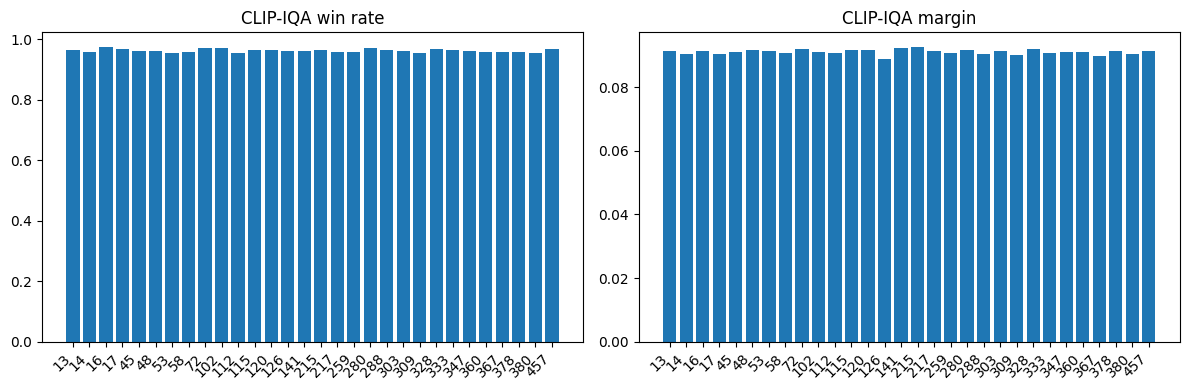


=== CLIP-IQA: mean +/- std across seeds ===
  clip_iqa_win_rate: 0.9624 +/- 0.0052  (n=30)
  clip_iqa_margin_mean: 0.0911 +/- 0.0008  (n=30)
Saved summary: qwen_caption_evaluation\clip_iqa\aggregation_mean_std.csv


In [12]:
def clip_cosine_similarity_batch(clip_model, clip_processor, paths, captions, device, batch_size):
    scores = []
    clip_model.eval()
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i : i + batch_size]
        batch_caps = captions[i : i + batch_size]
        images = load_pil_batch(batch_paths)
        inputs = clip_processor(text=batch_caps, images=images, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = clip_model(**inputs)
        img_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
        txt_emb = out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True)
        sim = (img_emb * txt_emb).sum(dim=-1).detach().cpu().numpy()
        scores.extend(sim.tolist())
    return np.array(scores, dtype=np.float32)


def run_clip_iqa_for_seeds(num_negatives: int = 5):
    out_dir = metric_dir("clip_iqa")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        seed_csv = out_dir / f"{seed_tag}_per_sample.csv"
        _, _, test_df = split_by_seed(df_full, seed)
        test_df = subsample_test_df(test_df).reset_index(drop=True)
        n = len(test_df)
        if seed_csv.is_file() and not OVERWRITE_EXISTING:
            per_seed = pd.read_csv(seed_csv)
        else:
            rng = np.random.default_rng(seed)
            paths, all_caps = test_df["abs_path"].tolist(), test_df["caption"].tolist()
            pos_sims = clip_cosine_similarity_batch(clip_model, clip_processor, paths, all_caps, device, EVAL_BATCH_SIZE)
            margins, wins = [], []
            for i in range(n):
                neg_idx = rng.choice([j for j in range(n) if j != i], size=min(num_negatives, max(1, n - 1)), replace=False)
                neg_caps = [all_caps[j] for j in neg_idx]
                neg_sims = clip_cosine_similarity_batch(
                    clip_model, clip_processor, [paths[i]] * len(neg_caps), neg_caps, device, EVAL_BATCH_SIZE,
                )
                margins.append(float(pos_sims[i] - neg_sims.mean()))
                wins.append(1.0 if pos_sims[i] > neg_sims.max() else 0.0)
            per_seed = test_df[["merge_key", "style"]].copy()
            per_seed["clip_iqa_margin"] = margins
            per_seed["clip_iqa_win"] = wins
            per_seed.to_csv(seed_csv, index=False)
        win_rate = float(per_seed["clip_iqa_win"].mean())
        margin = float(per_seed["clip_iqa_margin"].mean())
        print(f"[clip_iqa] {seed_tag} ({si}/{len(SEEDS)}): win_rate={win_rate:.4f} margin={margin:.4f}")
        rows.append({"seed": seed, "clip_iqa_win_rate": win_rate, "clip_iqa_margin_mean": margin, "n_test": n})
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(summary_df["seed"].astype(str), summary_df["clip_iqa_win_rate"])
    axes[0].set_title("CLIP-IQA win rate")
    axes[1].bar(summary_df["seed"].astype(str), summary_df["clip_iqa_margin_mean"])
    axes[1].set_title("CLIP-IQA margin")
    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / "clip_iqa_per_seed.png", dpi=150)
    plt.show()
    return summary_df

clip_iqa_summary = run_clip_iqa_for_seeds()
save_summary_csv(
    print_mean_std_table(clip_iqa_summary, ["clip_iqa_win_rate", "clip_iqa_margin_mean"], "CLIP-IQA"),
    metric_dir("clip_iqa") / "aggregation_mean_std.csv",
)


### BLIPScore

Image + Caption -> BLIP ITM head matching score. **Higher is better.**


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[blipscore] seed_13 (1/30): mean_itm=0.9598
[blipscore] seed_14 (2/30): mean_itm=0.9602
[blipscore] seed_16 (3/30): mean_itm=0.9615
[blipscore] seed_17 (4/30): mean_itm=0.9623
[blipscore] seed_45 (5/30): mean_itm=0.9553
[blipscore] seed_48 (6/30): mean_itm=0.9617
[blipscore] seed_53 (7/30): mean_itm=0.9579
[blipscore] seed_58 (8/30): mean_itm=0.9643
[blipscore] seed_72 (9/30): mean_itm=0.9610
[blipscore] seed_102 (10/30): mean_itm=0.9583
[blipscore] seed_112 (11/30): mean_itm=0.9540
[blipscore] seed_115 (12/30): mean_itm=0.9597
[blipscore] seed_120 (13/30): mean_itm=0.9608
[blipscore] seed_126 (14/30): mean_itm=0.9599
[blipscore] seed_141 (15/30): mean_itm=0.9580
[blipscore] seed_215 (16/30): mean_itm=0.9597
[blipscore] seed_217 (17/30): mean_itm=0.9615
[blipscore] seed_259 (18/30): mean_itm=0.9562
[blipscore] seed_280 (19/30): mean_itm=0.9582
[blipscore] seed_288 (20/30): mean_itm=0.9580
[blipscore] seed_303 (21/30): mean_itm=0.9606
[blipscore] seed_309 (22/30): mean_itm=0.9591
[blips

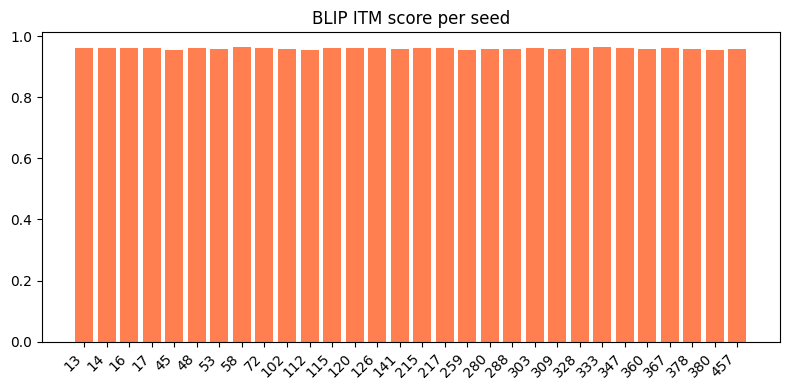


=== BLIPScore: mean +/- std across seeds ===
  blip_itm_mean: 0.9594 +/- 0.0024  (n=30)
Saved summary: qwen_caption_evaluation\blipscore\aggregation_mean_std.csv


In [13]:
def blip_itm_scores_batch(blip_model, blip_processor, paths, captions, device, batch_size):
    scores = []
    blip_model.eval()
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i : i + batch_size]
        batch_caps = captions[i : i + batch_size]
        images = load_pil_batch(batch_paths)
        inputs = blip_processor(images=images, text=batch_caps, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = blip_model(**inputs, use_itm_head=True)
            # itm_head outputs (batch, 2) logits: negative / positive match
            logits = out.itm_score
            if logits.ndim == 1:
                batch_scores = logits
            else:
                batch_scores = torch.softmax(logits, dim=-1)[:, 1]
            scores.extend(batch_scores.detach().cpu().numpy().reshape(-1).tolist())
    return np.array(scores, dtype=np.float32)


def run_blipscore_for_seeds():
    out_dir = metric_dir("blipscore")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    blip_model = BlipForImageTextRetrieval.from_pretrained(BLIP_ITM_MODEL_ID).to(device)
    blip_processor = BlipProcessor.from_pretrained(BLIP_ITM_MODEL_ID)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        seed_csv = out_dir / f"{seed_tag}_per_sample.csv"
        if seed_csv.is_file() and not OVERWRITE_EXISTING:
            per_seed = pd.read_csv(seed_csv)
            mean_score = float(per_seed["blip_itm_score"].mean())
        else:
            _, _, test_df = split_by_seed(df_full, seed)
            test_df = subsample_test_df(test_df)
            sc = blip_itm_scores_batch(
                blip_model, blip_processor, test_df["abs_path"].tolist(), test_df["caption"].tolist(), device, EVAL_BATCH_SIZE,
            )
            per_seed = test_df[["merge_key", "style"]].copy()
            per_seed["blip_itm_score"] = sc
            per_seed.to_csv(seed_csv, index=False)
            mean_score = float(np.mean(sc))
        print(f"[blipscore] {seed_tag} ({si}/{len(SEEDS)}): mean_itm={mean_score:.4f}")
        rows.append({"seed": seed, "blip_itm_mean": mean_score, "n_test": len(per_seed)})
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(summary_df["seed"].astype(str), summary_df["blip_itm_mean"], color="coral")
    ax.set_title("BLIP ITM score per seed")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / "blipscore_per_seed.png", dpi=150)
    plt.show()
    return summary_df

blip_summary = run_blipscore_for_seeds()
save_summary_csv(
    print_mean_std_table(blip_summary, ["blip_itm_mean"], "BLIPScore"),
    metric_dir("blipscore") / "aggregation_mean_std.csv",
)

### Retrieval Recall@K

CLIP embeddings on the test set; image-to-text and text-to-image Recall@K. **Higher is better.**


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[retrieval] seed_13 (1/30): {1: 0.33248730964467005, 5: 0.6263959390862944, 10: 0.7309644670050761}
[retrieval] seed_14 (2/30): {1: 0.34365482233502537, 5: 0.6314720812182741, 10: 0.7294416243654822}
[retrieval] seed_16 (3/30): {1: 0.33756345177664976, 5: 0.6015228426395939, 10: 0.7065989847715736}
[retrieval] seed_17 (4/30): {1: 0.3416243654822335, 5: 0.6131979695431472, 10: 0.7269035532994924}
[retrieval] seed_45 (5/30): {1: 0.3532994923857868, 5: 0.616751269035533, 10: 0.7238578680203046}
[retrieval] seed_48 (6/30): {1: 0.3583756345177665, 5: 0.6289340101522842, 10: 0.7395939086294416}
[retrieval] seed_53 (7/30): {1: 0.3456852791878173, 5: 0.6289340101522842, 10: 0.7289340101522843}
[retrieval] seed_58 (8/30): {1: 0.3517766497461929, 5: 0.6208121827411167, 10: 0.7370558375634517}
[retrieval] seed_72 (9/30): {1: 0.3604060913705584, 5: 0.6218274111675127, 10: 0.7253807106598985}
[retrieval] seed_102 (10/30): {1: 0.3446700507614213, 5: 0.615736040609137, 10: 0.7192893401015228}
[retrie

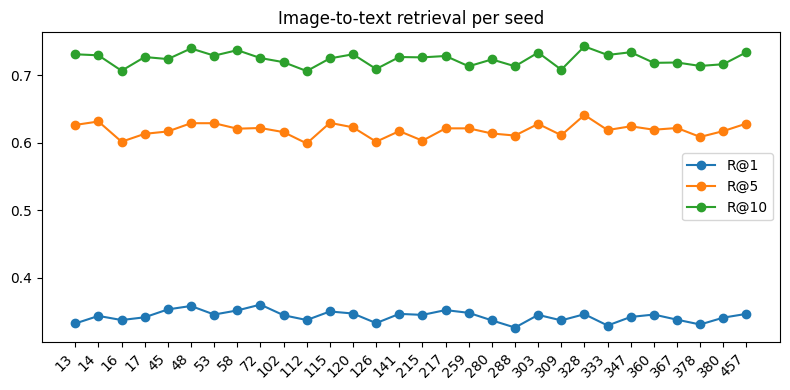

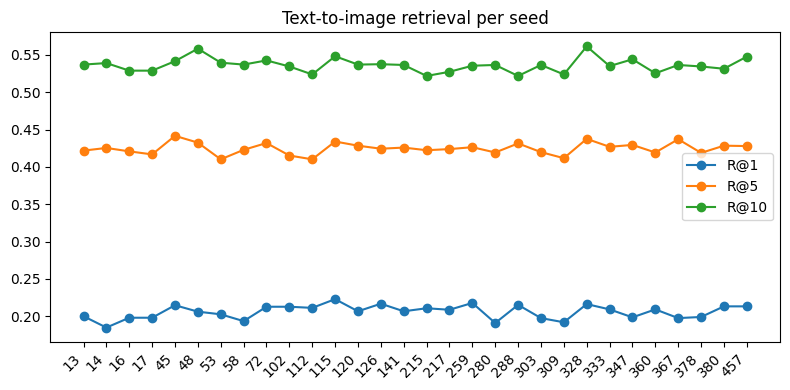


=== Retrieval Recall@K: mean +/- std across seeds ===
  i2t_recall@1: 0.3432 +/- 0.0081  (n=30)
  i2t_recall@5: 0.6188 +/- 0.0097  (n=30)
  i2t_recall@10: 0.7240 +/- 0.0098  (n=30)
  t2i_recall@1: 0.2058 +/- 0.0092  (n=30)
  t2i_recall@5: 0.4247 +/- 0.0078  (n=30)
  t2i_recall@10: 0.5364 +/- 0.0093  (n=30)
Saved summary: qwen_caption_evaluation\retrieval_recall\aggregation_mean_std.csv


In [14]:
def recall_at_k(sim_matrix: np.ndarray, k: int) -> float:
    n = sim_matrix.shape[0]
    hits = 0
    for i in range(n):
        order = np.argsort(-sim_matrix[i])
        topk = order[:k]
        if i in topk:
            hits += 1
    return hits / max(n, 1)


@torch.no_grad()
def clip_encode_images_texts(clip_model, clip_processor, paths, captions, device, batch_size):
    img_feats, txt_feats = [], []
    for i in range(0, len(paths), batch_size):
        bp, bc = paths[i : i + batch_size], captions[i : i + batch_size]
        images = load_pil_batch(bp)
        inputs = clip_processor(text=bc, images=images, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = clip_model(**inputs)
        img_feats.append(out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True))
        txt_feats.append(out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True))
    return torch.cat(img_feats, dim=0), torch.cat(txt_feats, dim=0)


def run_retrieval_for_seeds():
    out_dir = metric_dir("retrieval_recall")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        _, _, test_df = split_by_seed(df_full, seed)
        test_df = subsample_test_df(test_df).reset_index(drop=True)
        paths, caps = test_df["abs_path"].tolist(), test_df["caption"].tolist()
        img_e, txt_e = clip_encode_images_texts(clip_model, clip_processor, paths, caps, device, EVAL_BATCH_SIZE)
        sim_i2t = (img_e @ txt_e.T).cpu().numpy()
        sim_t2i = sim_i2t.T
        row = {"seed": seed, "n_test": len(test_df)}
        for k in RETRIEVAL_K_VALUES:
            row[f"i2t_recall@{k}"] = recall_at_k(sim_i2t, k)
            row[f"t2i_recall@{k}"] = recall_at_k(sim_t2i, k)
        print(f"[retrieval] {seed_tag} ({si}/{len(SEEDS)}):", {k: row[f"i2t_recall@{k}"] for k in RETRIEVAL_K_VALUES})
        rows.append(row)
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    for direction, prefix in [("Image-to-text", "i2t"), ("Text-to-image", "t2i")]:
        fig, ax = plt.subplots(figsize=(8, 4))
        for k in RETRIEVAL_K_VALUES:
            ax.plot(summary_df["seed"].astype(str), summary_df[f"{prefix}_recall@{k}"], marker="o", label=f"R@{k}")
        ax.set_title(f"{direction} retrieval per seed")
        ax.legend()
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(out_dir / f"{prefix}_recall_per_seed.png", dpi=150)
        plt.show()
    return summary_df

retrieval_summary = run_retrieval_for_seeds()
rec_cols = [f"i2t_recall@{k}" for k in RETRIEVAL_K_VALUES] + [f"t2i_recall@{k}" for k in RETRIEVAL_K_VALUES]
save_summary_csv(
    print_mean_std_table(retrieval_summary, rec_cols, "Retrieval Recall@K"),
    metric_dir("retrieval_recall") / "aggregation_mean_std.csv",
)

### Confusion Matrix (CLIP zero-shot style from image+caption)

Fuse image and text CLIP embeddings; nearest style prompt is the prediction. **Lower off-diagonal confusion is better.**


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[confusion] seed_13 (1/30): acc=0.2782 macro_f1=0.2029
[confusion] seed_14 (2/30): acc=0.2858 macro_f1=0.2142
[confusion] seed_16 (3/30): acc=0.2964 macro_f1=0.2241
[confusion] seed_17 (4/30): acc=0.2832 macro_f1=0.2104
[confusion] seed_45 (5/30): acc=0.2777 macro_f1=0.2018
[confusion] seed_48 (6/30): acc=0.2954 macro_f1=0.2207
[confusion] seed_53 (7/30): acc=0.2848 macro_f1=0.2097
[confusion] seed_58 (8/30): acc=0.2893 macro_f1=0.2156
[confusion] seed_72 (9/30): acc=0.2751 macro_f1=0.2023
[confusion] seed_102 (10/30): acc=0.2706 macro_f1=0.2027
[confusion] seed_112 (11/30): acc=0.2838 macro_f1=0.2096
[confusion] seed_115 (12/30): acc=0.2838 macro_f1=0.2143
[confusion] seed_120 (13/30): acc=0.2848 macro_f1=0.2066
[confusion] seed_126 (14/30): acc=0.3020 macro_f1=0.2278
[confusion] seed_141 (15/30): acc=0.2995 macro_f1=0.2296
[confusion] seed_215 (16/30): acc=0.2782 macro_f1=0.2081
[confusion] seed_217 (17/30): acc=0.2802 macro_f1=0.2084
[confusion] seed_259 (18/30): acc=0.2827 macro_f1

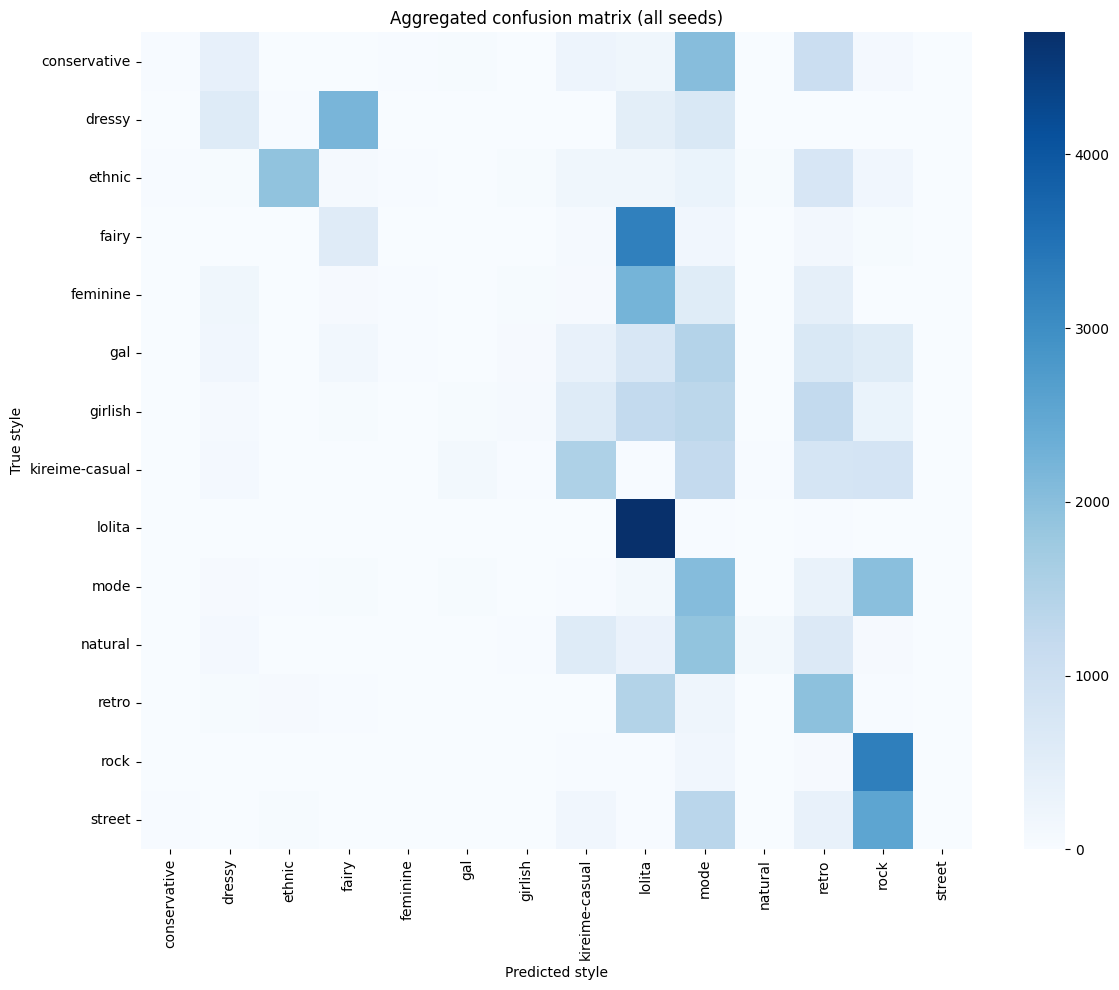

Saved aggregated confusion matrix.
    seed  accuracy  macro_f1  n_test
0     13  0.278173  0.202863    1970
1     14  0.285787  0.214206    1970
2     16  0.296447  0.224053    1970
3     17  0.283249  0.210356    1970
4     45  0.277665  0.201808    1970
5     48  0.295431  0.220731    1970
6     53  0.284772  0.209652    1970
7     58  0.289340  0.215588    1970
8     72  0.275127  0.202251    1970
9    102  0.270558  0.202673    1970
10   112  0.283756  0.209591    1970
11   115  0.283756  0.214271    1970
12   120  0.284772  0.206618    1970
13   126  0.302030  0.227842    1970
14   141  0.299492  0.229632    1970
15   215  0.278173  0.208079    1970
16   217  0.280203  0.208368    1970
17   259  0.282741  0.206934    1970
18   280  0.280203  0.213537    1970
19   288  0.301523  0.229014    1970
20   303  0.285279  0.211836    1970
21   309  0.291878  0.216665    1970
22   328  0.288832  0.215578    1970
23   333  0.279695  0.206903    1970
24   347  0.280203  0.208037    1970
25 

In [15]:
STYLE_PROMPTS = [f"a fashion outfit in the {s} style" for s in classes]

@torch.no_grad()
def clip_zero_shot_predict(clip_model, clip_processor, paths, captions, device, batch_size):
    text_inputs = clip_processor(text=STYLE_PROMPTS, return_tensors="pt", padding=True)
    text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
    text_emb = clip_model.get_text_features(**text_inputs)
    text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    preds = []
    for i in range(0, len(paths), batch_size):
        bp, bc = paths[i : i + batch_size], captions[i : i + batch_size]
        images = load_pil_batch(bp)
        img_inputs = clip_processor(images=images, return_tensors="pt")
        img_inputs = {k: v.to(device) for k, v in img_inputs.items()}
        img_emb = clip_model.get_image_features(**img_inputs)
        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
        cap_inputs = clip_processor(text=bc, return_tensors="pt", padding=True, truncation=True)
        cap_inputs = {k: v.to(device) for k, v in cap_inputs.items()}
        cap_emb = clip_model.get_text_features(**cap_inputs)
        cap_emb = cap_emb / cap_emb.norm(dim=-1, keepdim=True)
        fused = (img_emb + cap_emb) / (img_emb + cap_emb).norm(dim=-1, keepdim=True)
        logits = fused @ text_emb.T
        preds.extend(logits.argmax(dim=-1).cpu().tolist())
    return np.array(preds, dtype=int)


def run_confusion_matrix_for_seeds():
    out_dir = metric_dir("confusion_matrix")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        summary_df = pd.read_csv(summary_path)
    else:
        clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
        clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
        rows = []
        agg_cm = np.zeros((num_classes, num_classes), dtype=np.int64)
        for si, seed in enumerate(SEEDS, start=1):
            seed_tag = f"seed_{seed}"
            _, _, test_df = split_by_seed(df_full, seed)
            test_df = subsample_test_df(test_df).reset_index(drop=True)
            y_true = test_df["style"].map(style_to_idx).to_numpy()
            y_pred = clip_zero_shot_predict(
                clip_model, clip_processor, test_df["abs_path"].tolist(), test_df["caption"].tolist(), device, EVAL_BATCH_SIZE,
            )
            acc = accuracy_score(y_true, y_pred)
            macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
            cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
            agg_cm += cm
            per_seed = test_df[["merge_key", "style"]].copy()
            per_seed["pred_style"] = [idx_to_style[i] for i in y_pred]
            per_seed.to_csv(out_dir / f"{seed_tag}_predictions.csv", index=False)
            print(f"[confusion] {seed_tag} ({si}/{len(SEEDS)}): acc={acc:.4f} macro_f1={macro_f1:.4f}")
            rows.append({"seed": seed, "accuracy": acc, "macro_f1": macro_f1, "n_test": len(test_df)})
        summary_df = pd.DataFrame(rows)
        summary_df.to_csv(summary_path, index=False)
        np.save(out_dir / "aggregated_confusion_matrix.npy", agg_cm)
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(agg_cm, xticklabels=classes, yticklabels=classes, annot=False, fmt="d", cmap="Blues", ax=ax)
        ax.set_xlabel("Predicted style")
        ax.set_ylabel("True style")
        ax.set_title("Aggregated confusion matrix (all seeds)")
        plt.tight_layout()
        plt.savefig(out_dir / "confusion_matrix_aggregated.png", dpi=150)
        plt.show()
        print("Saved aggregated confusion matrix.")
    return summary_df

confusion_summary = run_confusion_matrix_for_seeds()
print(confusion_summary)
save_summary_csv(
    print_mean_std_table(confusion_summary, ["accuracy", "macro_f1"], "Confusion / zero-shot style"),
    metric_dir("confusion_matrix") / "aggregation_mean_std.csv",
)

### GPT-4o Evaluation

GPT-4o rates caption correctness and style consistency (1-5). Requires `OPENAI_API_KEY`. **Higher is better.**


In [16]:
from dotenv import load_dotenv
load_dotenv() 

True

[gpt4o] seed_13 (1/30): semantic=4.830 style=4.596
[gpt4o] seed_14 (2/30): semantic=4.755 style=4.653
[gpt4o] seed_16 (3/30): semantic=4.735 style=4.694
[gpt4o] seed_17 (4/30): semantic=4.776 style=4.755
[gpt4o] seed_45 (5/30): semantic=4.596 style=4.681
[gpt4o] seed_48 (6/30): semantic=4.812 style=4.458
[gpt4o] seed_53 (7/30): semantic=4.571 style=4.469
[gpt4o] seed_58 (8/30): semantic=4.818 style=4.659
[gpt4o] seed_72 (9/30): semantic=4.755 style=4.571
[gpt4o] seed_102 (10/30): semantic=4.750 style=4.604
[gpt4o] seed_112 (11/30): semantic=4.796 style=4.551
[gpt4o] seed_115 (12/30): semantic=4.812 style=4.667
[gpt4o] seed_120 (13/30): semantic=4.667 style=4.667
[gpt4o] seed_126 (14/30): semantic=4.771 style=4.604
[gpt4o] seed_141 (15/30): semantic=4.735 style=4.694
[gpt4o] seed_215 (16/30): semantic=4.833 style=4.604
[gpt4o] seed_217 (17/30): semantic=4.702 style=4.723
[gpt4o] seed_259 (18/30): semantic=4.729 style=4.708
[gpt4o] seed_280 (19/30): semantic=4.721 style=4.581
[gpt4o] see

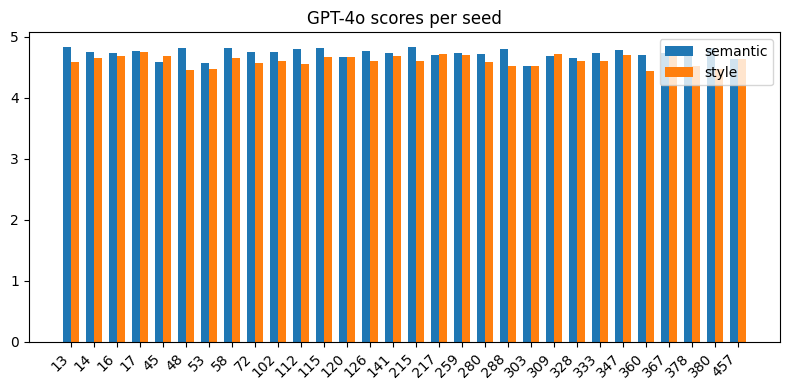


=== GPT-4o: mean +/- std across seeds ===
  gpt4o_semantic_mean: 4.7332 +/- 0.0762  (n=30)
  gpt4o_style_mean: 4.6129 +/- 0.0851  (n=30)
Saved summary: qwen_caption_evaluation\gpt4o_evaluation\aggregation_mean_std.csv


In [19]:
def run_gpt4o_for_seeds():
    out_dir = metric_dir("gpt4o_evaluation")
    summary_path = out_dir / "all_seeds_summary.csv"
    api_key = os.environ.get("OPENAI_API_KEY", "").strip()
    if not api_key and SKIP_GPT4O_IF_NO_KEY:
        print("OPENAI_API_KEY not set; skipping GPT-4o evaluation.")
        return pd.DataFrame()
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    try:
        from openai import OpenAI
    except ImportError:
        print("Install openai package: pip install openai")
        return pd.DataFrame()
    import base64
    from io import BytesIO

    client = OpenAI(api_key=api_key)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        seed_csv = out_dir / f"{seed_tag}_per_sample.csv"
        if seed_csv.is_file() and not OVERWRITE_EXISTING:
            per_seed = pd.read_csv(seed_csv)
        else:
            _, _, test_df = split_by_seed(df_full, seed)
            test_df = subsample_test_df(test_df).reset_index(drop=True)
            if GPT4O_MAX_SAMPLES_PER_SEED and len(test_df) > GPT4O_MAX_SAMPLES_PER_SEED:
                test_df = test_df.sample(n=GPT4O_MAX_SAMPLES_PER_SEED, random_state=seed).reset_index(drop=True)
            scores_sem, scores_style = [], []
            records = []
            for _, row in test_df.iterrows():
                img = Image.open(row["abs_path"]).convert("RGB")
                img.thumbnail((512, 512))
                buf = BytesIO()
                img.save(buf, format="JPEG", quality=85)
                b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
                prompt = (
                    f"Ground-truth fashion style label: {row['style']}. "
                    f"Caption: {row['caption']} "
                    "Rate (1-5): semantic_correctness, style_consistency. "
                    'Reply JSON only: {"semantic_correctness": int, "style_consistency": int}'
                )
                try:
                    resp = client.chat.completions.create(
                        model=GPT4O_MODEL,
                        messages=[{
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
                            ],
                        }],
                        max_tokens=80,
                    )
                    text = resp.choices[0].message.content or "{}"
                    m = re.search(r"\{[^}]+\}", text)
                    parsed = json.loads(m.group(0)) if m else {}
                    s1 = float(parsed.get("semantic_correctness", np.nan))
                    s2 = float(parsed.get("style_consistency", np.nan))
                except Exception as exc:
                    print("GPT-4o error:", exc)
                    s1, s2 = np.nan, np.nan
                scores_sem.append(s1)
                scores_style.append(s2)
                records.append({"merge_key": row["merge_key"], "semantic": s1, "style_fit": s2})
            per_seed = pd.DataFrame(records)
            per_seed.to_csv(seed_csv, index=False)
        mean_sem = float(per_seed["semantic"].mean())
        mean_style = float(per_seed["style_fit"].mean())
        print(f"[gpt4o] {seed_tag} ({si}/{len(SEEDS)}): semantic={mean_sem:.3f} style={mean_style:.3f}")
        rows.append({"seed": seed, "gpt4o_semantic_mean": mean_sem, "gpt4o_style_mean": mean_style, "n_test": len(per_seed)})
    summary_df = pd.DataFrame(rows)
    if len(summary_df):
        summary_df.to_csv(summary_path, index=False)
        fig, ax = plt.subplots(figsize=(8, 4))
        x = np.arange(len(summary_df))
        w = 0.35
        ax.bar(x - w / 2, summary_df["gpt4o_semantic_mean"], width=w, label="semantic")
        ax.bar(x + w / 2, summary_df["gpt4o_style_mean"], width=w, label="style")
        ax.set_xticks(x)
        ax.set_xticklabels(summary_df["seed"].astype(str), rotation=45, ha="right")
        ax.legend()
        ax.set_title("GPT-4o scores per seed")
        plt.tight_layout()
        plt.savefig(out_dir / "gpt4o_per_seed.png", dpi=150)
        plt.show()
    return summary_df

gpt4o_summary = run_gpt4o_for_seeds()
if len(gpt4o_summary):
    save_summary_csv(
        print_mean_std_table(gpt4o_summary, ["gpt4o_semantic_mean", "gpt4o_style_mean"], "GPT-4o"),
        metric_dir("gpt4o_evaluation") / "aggregation_mean_std.csv",
    )

### Random Caption Sanity Check

Train frozen CLIP+BERT fusion classifier; compare test accuracy with correct vs shuffled captions. **Larger drop is better.**


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[random_sanity] seed_13 (1/30): correct=0.8173 random=0.7569 drop=0.0604


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[random_sanity] seed_14 (2/30): correct=0.8335 random=0.7832 drop=0.0503


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


...

[random_sanity] seed_378 (28/30): correct=0.8396 random=0.7843 drop=0.0553


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[random_sanity] seed_380 (29/30): correct=0.8203 random=0.7492 drop=0.0711


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[random_sanity] seed_457 (30/30): correct=0.8193 random=0.7640 drop=0.0553


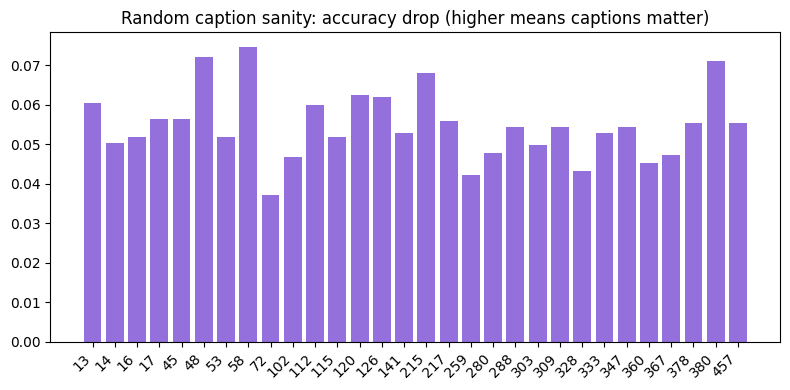


=== Random Caption Sanity: mean +/- std across seeds ===
  acc_correct_caption: 0.8284 +/- 0.0082  (n=30)
  acc_random_caption: 0.7736 +/- 0.0121  (n=30)
  accuracy_drop: 0.0548 +/- 0.0087  (n=30)
Saved summary: qwen_caption_evaluation\random_caption_sanity\aggregation_mean_std.csv


In [21]:
class FusionRowDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, caption_col: str = "caption"):
        self.frame = frame.reset_index(drop=True)
        self.caption_col = caption_col

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        return {"abs_path": row["abs_path"], "caption": str(row[self.caption_col]), "label": style_to_idx[row["style"]]}


class ClipBertFusionClassifier(nn.Module):
    def __init__(self, clip_model, clip_processor, bert_model, bert_tokenizer, num_classes, dropout=SANITY_DROPOUT):
        super().__init__()
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.bert_model = bert_model
        self.bert_tokenizer = bert_tokenizer
        for p in list(self.clip_model.parameters()) + list(self.bert_model.parameters()):
            p.requires_grad = False
        vd = clip_model.config.projection_dim
        td = bert_model.config.hidden_size
        self.fusion = nn.Sequential(nn.Linear(vd + td, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU())
        self.classifier = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, num_classes))

    def forward(self, pixel_values, captions):
        dev = pixel_values.device
        with torch.no_grad():
            visual = self.clip_model.get_image_features(pixel_values=pixel_values).float()
            enc = self.bert_tokenizer(captions, return_tensors="pt", padding=True, truncation=True, max_length=128).to(dev)
            textual = self.bert_model(**enc).last_hidden_state[:, 0, :].float()
        fused = self.fusion(torch.cat([visual, textual], dim=-1))
        return self.classifier(fused)


def collate_fusion(batch, clip_processor, device):
    # DataLoader default_collate: list[dict] -> dict of lists/tensors
    if isinstance(batch, dict):
        paths = list(batch["abs_path"])
        caps = list(batch["caption"])
        labels = batch["label"]
        if not isinstance(labels, torch.Tensor):
            labels = torch.tensor(labels, dtype=torch.long)
    else:
        paths = [b["abs_path"] for b in batch]
        caps = [b["caption"] for b in batch]
        labels = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    images = load_pil_batch(paths)
    px = clip_processor(images=images, return_tensors="pt")["pixel_values"].to(device)
    return px, caps, labels


def train_fusion_classifier(train_df, val_df, device):
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    bert_model = AutoModel.from_pretrained(BERT_MODEL_ID).to(device)
    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_ID)
    model = ClipBertFusionClassifier(clip_model, clip_processor, bert_model, bert_tokenizer, num_classes).to(device)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=SANITY_LR)
    crit = nn.CrossEntropyLoss()
    train_loader = DataLoader(FusionRowDataset(train_df), batch_size=SANITY_BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FusionRowDataset(val_df), batch_size=SANITY_BATCH_SIZE, shuffle=False)
    best_f1, best_state = -1.0, None
    for epoch in range(SANITY_TRAIN_EPOCHS):
        model.train()
        for batch in train_loader:
            px, caps, y = collate_fusion(batch, clip_processor, device)
            opt.zero_grad()
            logits = model(px, caps)
            loss = crit(logits, y.to(device))
            loss.backward()
            opt.step()
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                px, caps, y = collate_fusion(batch, clip_processor, device)
                preds.extend(model(px, caps).argmax(1).cpu().tolist())
                labels.extend(y.tolist())
        vf1 = f1_score(labels, preds, average="macro", zero_division=0)
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model, clip_processor


@torch.no_grad()
def eval_fusion_accuracy(model, clip_processor, test_df, device, caption_col="caption"):
    loader = DataLoader(FusionRowDataset(test_df, caption_col=caption_col), batch_size=SANITY_BATCH_SIZE, shuffle=False)
    preds, labels = [], []
    model.eval()
    for batch in loader:
        px, caps, y = collate_fusion(batch, clip_processor, device)
        preds.extend(model(px, caps).argmax(1).cpu().tolist())
        labels.extend(y.tolist())
    return accuracy_score(labels, preds)


def run_random_caption_sanity():
    out_dir = metric_dir("random_caption_sanity")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        train_df, val_df, test_df = split_by_seed(df_full, seed)
        test_df = subsample_test_df(test_df).reset_index(drop=True)
        model, clip_processor = train_fusion_classifier(train_df, val_df, device)
        acc_correct = eval_fusion_accuracy(model, clip_processor, test_df, device, caption_col="caption")
        shuffled = test_df.copy()
        rng = np.random.default_rng(RANDOM_CAPTION_SANITY_SEED + seed)
        shuffled["caption_random"] = rng.permutation(shuffled["caption"].values)
        acc_random = eval_fusion_accuracy(model, clip_processor, shuffled, device, caption_col="caption_random")
        drop = acc_correct - acc_random
        print(f"[random_sanity] {seed_tag} ({si}/{len(SEEDS)}): correct={acc_correct:.4f} random={acc_random:.4f} drop={drop:.4f}")
        rows.append({"seed": seed, "acc_correct_caption": acc_correct, "acc_random_caption": acc_random, "accuracy_drop": drop})
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(summary_df["seed"].astype(str), summary_df["accuracy_drop"], color="mediumpurple")
    ax.set_title("Random caption sanity: accuracy drop (higher means captions matter)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / "random_caption_drop_per_seed.png", dpi=150)
    plt.show()
    return summary_df

random_sanity_summary = run_random_caption_sanity()
save_summary_csv(
    print_mean_std_table(random_sanity_summary, ["acc_correct_caption", "acc_random_caption", "accuracy_drop"], "Random Caption Sanity"),
    metric_dir("random_caption_sanity") / "aggregation_mean_std.csv",
)

### Class-Randomized Sanity Check

Same fusion classifier; captions swapped from a different style class. **Larger accuracy drop is better.**


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[class_sanity] seed_13 (1/30): correct=0.8198 wrong_style=0.7533 drop=0.0665


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[class_sanity] seed_14 (2/30): correct=0.8239 wrong_style=0.7701 drop=0.0538


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


...

[class_sanity] seed_378 (28/30): correct=0.8122 wrong_style=0.7675 drop=0.0447


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[class_sanity] seed_380 (29/30): correct=0.8325 wrong_style=0.7827 drop=0.0497


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[class_sanity] seed_457 (30/30): correct=0.8208 wrong_style=0.7431 drop=0.0777


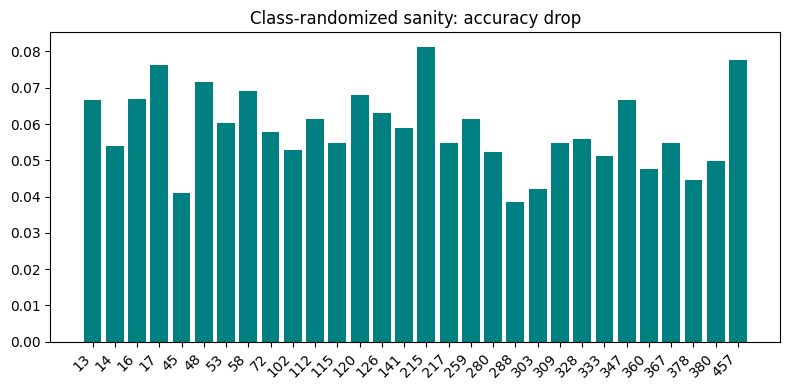


=== Class-Randomized Sanity: mean +/- std across seeds ===
  acc_correct_caption: 0.8271 +/- 0.0093  (n=30)
  acc_wrong_style_caption: 0.7686 +/- 0.0136  (n=30)
  accuracy_drop: 0.0585 +/- 0.0106  (n=30)
Saved summary: qwen_caption_evaluation\class_randomized_sanity\aggregation_mean_std.csv


In [22]:
class FusionRowDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, caption_col: str = "caption"):
        self.frame = frame.reset_index(drop=True)
        self.caption_col = caption_col

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        return {"abs_path": row["abs_path"], "caption": str(row[self.caption_col]), "label": style_to_idx[row["style"]]}


class ClipBertFusionClassifier(nn.Module):
    def __init__(self, clip_model, clip_processor, bert_model, bert_tokenizer, num_classes, dropout=SANITY_DROPOUT):
        super().__init__()
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.bert_model = bert_model
        self.bert_tokenizer = bert_tokenizer
        for p in list(self.clip_model.parameters()) + list(self.bert_model.parameters()):
            p.requires_grad = False
        vd = clip_model.config.projection_dim
        td = bert_model.config.hidden_size
        self.fusion = nn.Sequential(nn.Linear(vd + td, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU())
        self.classifier = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, num_classes))

    def forward(self, pixel_values, captions):
        dev = pixel_values.device
        with torch.no_grad():
            visual = self.clip_model.get_image_features(pixel_values=pixel_values).float()
            enc = self.bert_tokenizer(captions, return_tensors="pt", padding=True, truncation=True, max_length=128).to(dev)
            textual = self.bert_model(**enc).last_hidden_state[:, 0, :].float()
        fused = self.fusion(torch.cat([visual, textual], dim=-1))
        return self.classifier(fused)


def collate_fusion(batch, clip_processor, device):
    # DataLoader default_collate: list[dict] -> dict of lists/tensors
    if isinstance(batch, dict):
        paths = list(batch["abs_path"])
        caps = list(batch["caption"])
        labels = batch["label"]
        if not isinstance(labels, torch.Tensor):
            labels = torch.tensor(labels, dtype=torch.long)
    else:
        paths = [b["abs_path"] for b in batch]
        caps = [b["caption"] for b in batch]
        labels = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    images = load_pil_batch(paths)
    px = clip_processor(images=images, return_tensors="pt")["pixel_values"].to(device)
    return px, caps, labels


def train_fusion_classifier(train_df, val_df, device):
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    bert_model = AutoModel.from_pretrained(BERT_MODEL_ID).to(device)
    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_ID)
    model = ClipBertFusionClassifier(clip_model, clip_processor, bert_model, bert_tokenizer, num_classes).to(device)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=SANITY_LR)
    crit = nn.CrossEntropyLoss()
    train_loader = DataLoader(FusionRowDataset(train_df), batch_size=SANITY_BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FusionRowDataset(val_df), batch_size=SANITY_BATCH_SIZE, shuffle=False)
    best_f1, best_state = -1.0, None
    for epoch in range(SANITY_TRAIN_EPOCHS):
        model.train()
        for batch in train_loader:
            px, caps, y = collate_fusion(batch, clip_processor, device)
            opt.zero_grad()
            logits = model(px, caps)
            loss = crit(logits, y.to(device))
            loss.backward()
            opt.step()
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                px, caps, y = collate_fusion(batch, clip_processor, device)
                preds.extend(model(px, caps).argmax(1).cpu().tolist())
                labels.extend(y.tolist())
        vf1 = f1_score(labels, preds, average="macro", zero_division=0)
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model, clip_processor


@torch.no_grad()
def eval_fusion_accuracy(model, clip_processor, test_df, device, caption_col="caption"):
    loader = DataLoader(FusionRowDataset(test_df, caption_col=caption_col), batch_size=SANITY_BATCH_SIZE, shuffle=False)
    preds, labels = [], []
    model.eval()
    for batch in loader:
        px, caps, y = collate_fusion(batch, clip_processor, device)
        preds.extend(model(px, caps).argmax(1).cpu().tolist())
        labels.extend(y.tolist())
    return accuracy_score(labels, preds)


def run_class_randomized_sanity():
    out_dir = metric_dir("class_randomized_sanity")
    summary_path = out_dir / "all_seeds_summary.csv"
    if summary_path.is_file() and not OVERWRITE_EXISTING:
        return pd.read_csv(summary_path)
    rows = []
    for si, seed in enumerate(SEEDS, start=1):
        seed_tag = f"seed_{seed}"
        train_df, val_df, test_df = split_by_seed(df_full, seed)
        test_df = subsample_test_df(test_df).reset_index(drop=True)
        model, clip_processor = train_fusion_classifier(train_df, val_df, device)
        acc_correct = eval_fusion_accuracy(model, clip_processor, test_df, device, caption_col="caption")
        wrong = test_df.copy()
        rng = np.random.default_rng(CLASS_RANDOM_SANITY_SEED + seed)
        wrong_caps = []
        for _, row in wrong.iterrows():
            candidates = df_full[df_full["style"] != row["style"]]["caption"].values
            wrong_caps.append(rng.choice(candidates))
        wrong["caption_wrong_style"] = wrong_caps
        acc_wrong = eval_fusion_accuracy(model, clip_processor, wrong, device, caption_col="caption_wrong_style")
        drop = acc_correct - acc_wrong
        print(f"[class_sanity] {seed_tag} ({si}/{len(SEEDS)}): correct={acc_correct:.4f} wrong_style={acc_wrong:.4f} drop={drop:.4f}")
        rows.append({"seed": seed, "acc_correct_caption": acc_correct, "acc_wrong_style_caption": acc_wrong, "accuracy_drop": drop})
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(summary_path, index=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(summary_df["seed"].astype(str), summary_df["accuracy_drop"], color="teal")
    ax.set_title("Class-randomized sanity: accuracy drop")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / "class_randomized_drop_per_seed.png", dpi=150)
    plt.show()
    return summary_df

class_sanity_summary = run_class_randomized_sanity()
save_summary_csv(
    print_mean_std_table(class_sanity_summary, ["acc_correct_caption", "acc_wrong_style_caption", "accuracy_drop"], "Class-Randomized Sanity"),
    metric_dir("class_randomized_sanity") / "aggregation_mean_std.csv",
)

## 5. Global cross-metric summary

Collect per-metric aggregation CSVs into one table.


In [23]:
def load_agg(metric_name: str) -> pd.DataFrame:
    p = metric_dir(metric_name) / "aggregation_mean_std.csv"
    if p.is_file():
        df = pd.read_csv(p)
        df.insert(0, "metric_group", metric_name)
        return df
    return pd.DataFrame()

parts = [
    load_agg("clip_similarity"),
    load_agg("clip_iqa"),
    load_agg("blipscore"),
    load_agg("retrieval_recall"),
    load_agg("confusion_matrix"),
    load_agg("gpt4o_evaluation"),
    load_agg("random_caption_sanity"),
    load_agg("class_randomized_sanity"),
]
global_summary = pd.concat([p for p in parts if len(p)], ignore_index=True)
global_path = RESULTS_ROOT / "global_aggregation_mean_std.csv"
global_summary.to_csv(global_path, index=False)
print("Global aggregation saved:", global_path)
print(global_summary.to_string(index=False))

Global aggregation saved: qwen_caption_evaluation\global_aggregation_mean_std.csv
           metric_group                  metric     mean      std
        clip_similarity    clip_similarity_mean 0.316645 0.000634
               clip_iqa       clip_iqa_win_rate 0.962403 0.005165
               clip_iqa    clip_iqa_margin_mean 0.091128 0.000754
              blipscore           blip_itm_mean 0.959398 0.002399
       retrieval_recall            i2t_recall@1 0.343198 0.008052
       retrieval_recall            i2t_recall@5 0.618816 0.009721
       retrieval_recall           i2t_recall@10 0.723993 0.009767
       retrieval_recall            t2i_recall@1 0.205838 0.009199
       retrieval_recall            t2i_recall@5 0.424738 0.007784
       retrieval_recall           t2i_recall@10 0.536362 0.009328
       confusion_matrix                accuracy 0.285533 0.008176
       confusion_matrix                macro_f1 0.212785 0.008133
       gpt4o_evaluation     gpt4o_semantic_mean 4.733178 0.0